In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, ParameterGrid
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import shutil
import os
from google.colab import drive

In [2]:
drive.mount('/content/drive')
print("Google Drive successfully mounted.")

Mounted at /content/drive
Google Drive successfully mounted.


In [3]:
# Automatically create the 'machine_learning_models' folder if it doesn't exist
DRIVE_MODEL_PATH = '/content/drive/MyDrive/machine_learning_models'

# Create the folder if it doesn't exist
os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)
print(f"Target folder '{DRIVE_MODEL_PATH}' checked/created.")

# Filenames to save
MODEL_FILENAME = 'random_forest_churn_model.pkl'
LR_MODEL_FILENAME = 'logistic_regression_churn_model.pkl'
XGB_MODEL_FILENAME = 'xgboost_churn_model.pkl'
LINEAR_SVC_MODEL_FILENAME = 'linear_svc_churn_model.pkl'
KNN_MODEL_FILENAME = 'knn_churn_model.pkl'
MLP_MODEL_FILENAME = 'mlp_churn_model.pkl'
SCALER_FILENAME = 'standard_scaler.pkl'

Target folder '/content/drive/MyDrive/machine_learning_models' checked/created.


In [4]:
url = "https://raw.githubusercontent.com/uras-alkaya/AI-Projects/refs/heads/main/churn_features_final.csv"
df = pd.read_csv(url)

X = df.drop("churn", axis=1)
y = df["churn"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Original Distribution:", Counter(y_train))
print("Balanced Distribution:", Counter(y_train_res))

Original Distribution: Counter({0: 37878, 1: 10029})
Balanced Distribution: Counter({1: 37878, 0: 37878})


In [ ]:
# Parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 7],
}

# Manual GridSearch
grid = ParameterGrid(param_grid)
best_score = 0
best_params = None

print("GridSearch for RandomForestClassifier has started...\n")

for params in tqdm(grid, desc="RandomForest GridSearch Progress"):
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)

    score = f1_score(y_test, y_pred)
    print(f"Trying parameters: {params} | F1 Score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = params

print(f"\nBest Params: {best_params}")
print(f"Best Score: {best_score:.4f}")

GridSearch for RandomForestClassifier has started...



RandomForest GridSearch Progress:  12%|█▎        | 1/8 [00:36<04:17, 36.76s/it]

Trying parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100} | F1 Score: 0.6938


RandomForest GridSearch Progress:  25%|██▌       | 2/8 [01:45<05:32, 55.45s/it]

Trying parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200} | F1 Score: 0.6957


...

Trying parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} | F1 Score: 0.7126


RandomForest GridSearch Progress:  88%|████████▊ | 7/8 [04:44<00:33, 33.63s/it]

Trying parameters: {'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 100} | F1 Score: 0.7140


RandomForest GridSearch Progress: 100%|██████████| 8/8 [05:23<00:00, 40.48s/it]

Trying parameters: {'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 200} | F1 Score: 0.7140

Best Params: {'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 100}
Best Score: 0.7140


In [ ]:
# After GridSearch, train the final model using the best parameters
best_params = {'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 100}
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train_res)

RandomForestClassifier(max_depth=10, min_samples_split=7, random_state=42)

In [ ]:
# First, save the model temporarily in Colab directory
temp_model_path = os.path.join('/content', MODEL_FILENAME)
with open(temp_model_path, 'wb') as file:
    pickle.dump(final_model, file)
print(f"Model '{MODEL_FILENAME}' temporarily saved.")

temp_scaler_path = os.path.join('/content', SCALER_FILENAME)
with open(temp_scaler_path, 'wb') as file:
    pickle.dump(scaler, file)
print(f"Scaler '{SCALER_FILENAME}' temporarily saved.")

# Copy temporary files to Google Drive
shutil.copy(temp_model_path, os.path.join(DRIVE_MODEL_PATH, MODEL_FILENAME))
shutil.copy(temp_scaler_path, os.path.join(DRIVE_MODEL_PATH, SCALER_FILENAME))

print(f"\nModel and scaler successfully copied to '{DRIVE_MODEL_PATH}' folder.")

Model 'random_forest_churn_model.pkl' temporarily saved.
Scaler 'standard_scaler.pkl' temporarily saved.

Model and scaler successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [5]:
# Full paths of model and scaler to be loaded from Google Drive
LOAD_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, MODEL_FILENAME)
LOAD_SCALER_PATH = os.path.join(DRIVE_MODEL_PATH, SCALER_FILENAME)

loaded_model = None
loaded_scaler = None

# Load Model
try:
    with open(LOAD_MODEL_PATH, 'rb') as file:
        loaded_model = pickle.load(file)
    print(f"Model '{LOAD_MODEL_PATH}' successfully loaded.")
except FileNotFoundError:
    print(f"Error: Model file '{LOAD_MODEL_PATH}' not found. Please check the path or ensure the model is trained and saved first.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

# Load Scaler
try:
    with open(LOAD_SCALER_PATH, 'rb') as file:
        loaded_scaler = pickle.load(file)
    print(f"Scaler '{LOAD_SCALER_PATH}' successfully loaded.")
except FileNotFoundError:
    print(f"Error: Scaler file '{LOAD_SCALER_PATH}' not found. Please check the path or ensure the scaler is trained and saved first.")
except Exception as e:
    print(f"An error occurred while loading the scaler: {e}")

Model '/content/drive/MyDrive/machine_learning_models/random_forest_churn_model.pkl' successfully loaded.
Scaler '/content/drive/MyDrive/machine_learning_models/standard_scaler.pkl' successfully loaded.


In [6]:
# Make predictions with the final model
y_pred_final = loaded_model.predict(X_test_scaled)
y_pred_proba_final = loaded_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate final model
print("F1 Score:", f1_score(y_test, y_pred_final))
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

F1 Score: 0.7140046503308889
Accuracy: 0.8664941137179594
ROC AUC: 0.9133828869450648

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91      9470
           1       0.65      0.80      0.71      2507

    accuracy                           0.87     11977
   macro avg       0.79      0.84      0.81     11977
weighted avg       0.88      0.87      0.87     11977


Confusion Matrix:
 [[8382 1088]
 [ 511 1996]]


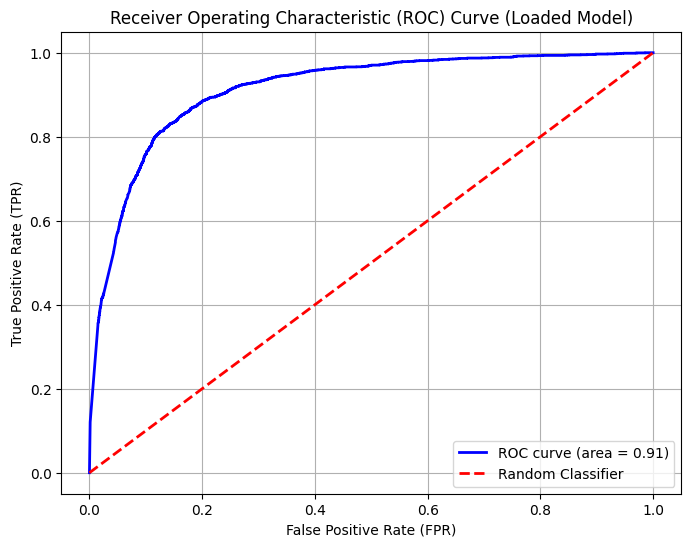

In [7]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba_final):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Loaded Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization ---



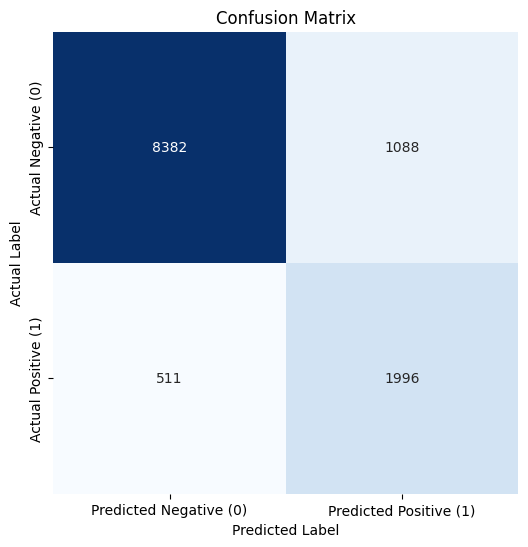

In [8]:
# Confusion Matrix Visualization
print("\n--- Confusion Matrix Visualization ---\n")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [9]:
# --- Prediction Results Table ---
results_df = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn': y_pred_final,
    'Predicted_Probability_Churn': y_pred_proba_final
})

print("\n--- Prediction Results Table ---\n")
print(results_df)


--- Prediction Results Table ---

       True_Churn  Predicted_Churn  Predicted_Probability_Churn
0               0                0                     0.294776
1               0                0                     0.381336
2               0                0                     0.062648
3               0                0                     0.164557
4               1                1                     0.993700
...           ...              ...                          ...
11972           0                0                     0.052027
11973           0                0                     0.310426
11974           1                1                     0.993700
11975           0                0                     0.048957
11976           0                0                     0.149222

[11977 rows x 3 columns]


In [10]:
# Find incorrect predictions
incorrect_predictions = results_df[results_df['True_Churn'] != results_df['Predicted_Churn']]

print("\n--- Rows Where Model Made Mistakes ---")
print(incorrect_predictions)


--- Rows Where Model Made Mistakes ---
       True_Churn  Predicted_Churn  Predicted_Probability_Churn
5               0                1                     0.856984
9               0                1                     0.549333
22              1                0                     0.237269
23              1                0                     0.227523
24              0                1                     0.850337
...           ...              ...                          ...
11906           0                1                     0.850337
11910           1                0                     0.136003
11915           0                1                     0.856418
11948           0                1                     0.728738
11949           0                1                     0.509641

[1599 rows x 3 columns]


In [11]:
incorrect_predictions = results_df[results_df['True_Churn'] != results_df['Predicted_Churn']]

false_positives = incorrect_predictions[incorrect_predictions['True_Churn'] == 0]
false_negatives = incorrect_predictions[incorrect_predictions['True_Churn'] == 1]

print(f"\nTotal Number of Incorrect Predictions: {len(incorrect_predictions)}")
print(f"False Positives (FP): {len(false_positives)}")
print(f"False Negatives (FN): {len(false_negatives)}")


Total Number of Incorrect Predictions: 1599
False Positives (FP): 1088
False Negatives (FN): 511


In [12]:
# Feature Importance Scores
feature_importances = loaded_model.feature_importances_
features = X.columns

# Convert feature importances to DataFrame
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance Scores (RandomForestClassfier):\n")
print(importance_df)


Feature Importance Scores (RandomForestClassfier):

                                       Feature  Importance
4                               user_spendings    0.121208
43                        avg_spending_per_day    0.082983
44              spending_per_call_out_duration    0.078123
33            last_100_calls_outgoing_duration    0.068093
15                 calls_outgoing_duration_max    0.066929
13                     calls_outgoing_duration    0.049837
11                        calls_outgoing_count    0.048129
46                       call_duration_per_day    0.047544
14                calls_outgoing_spendings_max    0.042097
47                          sms_inactive_ratio    0.028564
28                          sms_incoming_count    0.028361
35  last_100_calls_outgoing_to_offnet_duration    0.025884
48          spending_per_last100_call_duration    0.024090
17              calls_outgoing_to_offnet_count    0.023961
12                    calls_outgoing_spendings    0.023558
42 

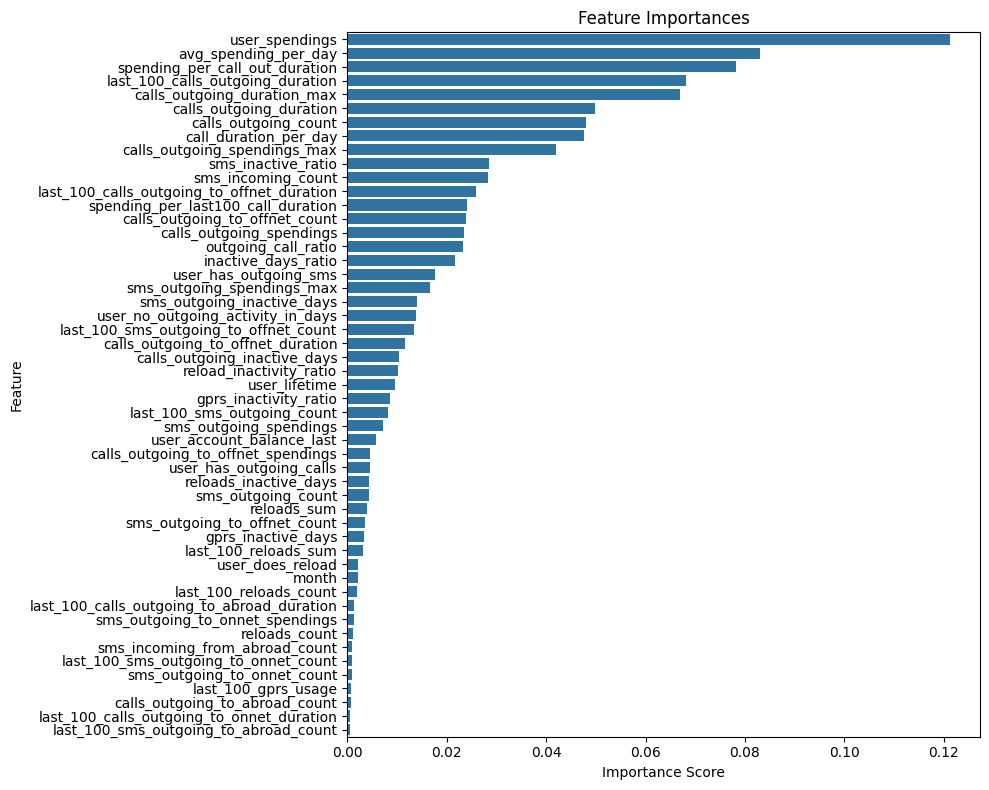

In [13]:
# Visualize Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter grid for LogisticRegression
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = ParameterGrid(param_grid_lr)
best_score_lr = 0
best_params_lr = None

print("GridSearch for Logistic Regression has started...\n")

for params in tqdm(grid_lr, desc="LR GridSearch Progress"):
    model_lr = LogisticRegression(**params, random_state=42)
    model_lr.fit(X_train_scaled, y_train_res)
    y_pred_lr = model_lr.predict(X_test_scaled)

    score_lr = f1_score(y_test, y_pred_lr)

    print(f"Trying parameters: {params} | F1 Score: {score_lr:.4f}")

    if score_lr > best_score_lr:
        best_score_lr = score_lr
        best_params_lr = params

print(f"\nBest Params for Logistic Regression: {best_params_lr}")
print(f"Best Score for Logistic Regression: {best_score_lr:.4f}")

GridSearch for Logistic Regression has started...



LR GridSearch Progress:  12%|█▎        | 1/8 [00:03<00:27,  3.86s/it]

Trying parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'} | F1 Score: 0.6673


LR GridSearch Progress:  25%|██▌       | 2/8 [00:07<00:21,  3.63s/it]

Trying parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'} | F1 Score: 0.6677


...

Trying parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'} | F1 Score: 0.6680


LR GridSearch Progress:  88%|████████▊ | 7/8 [00:23<00:03,  3.39s/it]

Trying parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'} | F1 Score: 0.6677


LR GridSearch Progress: 100%|██████████| 8/8 [00:25<00:00,  3.23s/it]

Trying parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'} | F1 Score: 0.6681

Best Params for Logistic Regression: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score for Logistic Regression: 0.6681


In [ ]:
best_params_lr = {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
final_model_lr = LogisticRegression(**best_params_lr, random_state=42)
final_model_lr.fit(X_train_scaled, y_train_res)

LogisticRegression(C=100, random_state=42, solver='liblinear')

In [ ]:
# Save temporarily to Colab's directory
temp_lr_model_path = os.path.join('/content', LR_MODEL_FILENAME)
with open(temp_lr_model_path, 'wb') as file:
    pickle.dump(final_model_lr, file)
print(f"Logistic Regression model '{LR_MODEL_FILENAME}' saved temporarily.")

# Copy the temporary file to Google Drive
shutil.copy(temp_lr_model_path, os.path.join(DRIVE_MODEL_PATH, LR_MODEL_FILENAME))
print(f"\nLogistic Regression model successfully copied to '{DRIVE_MODEL_PATH}' folder.")

Logistic Regression model 'logistic_regression_churn_model.pkl' saved temporarily.

Logistic Regression model successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [14]:
# Full paths of model to be loaded from Google Drive
LOAD_LR_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, LR_MODEL_FILENAME)

loaded_lr_model = None

# Load the Logistic Regression model
try:
    with open(LOAD_LR_MODEL_PATH, 'rb') as file:
        loaded_lr_model = pickle.load(file)
    print(f"Logistic Regression model loaded successfully from '{LOAD_LR_MODEL_PATH}'.")
except FileNotFoundError:
    print(f"Error: Logistic Regression model file '{LOAD_LR_MODEL_PATH}' not found. Please check the path or train and save the model first.")
except Exception as e:
    print(f"An error occurred while loading the Logistic Regression model: {e}")

Logistic Regression model loaded successfully from '/content/drive/MyDrive/machine_learning_models/logistic_regression_churn_model.pkl'.


In [15]:
# Make predictions using the final Logistic Regression model
y_pred_lr_final = loaded_lr_model.predict(X_test_scaled)
y_pred_proba_lr_final = loaded_lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the final Logistic Regression model
print("F1 Score (Logistic Regression):", f1_score(y_test, y_pred_lr_final))
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr_final))
print("ROC AUC (Logistic Regression):", roc_auc_score(y_test, y_pred_proba_lr_final))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr_final))
print("\nConfusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, y_pred_lr_final))

F1 Score (Logistic Regression): 0.6680645161290323
Accuracy (Logistic Regression): 0.8281706604324957
ROC AUC (Logistic Regression): 0.8947180207983644

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.95      0.83      0.88      9470
           1       0.56      0.83      0.67      2507

    accuracy                           0.83     11977
   macro avg       0.75      0.83      0.78     11977
weighted avg       0.87      0.83      0.84     11977


Confusion Matrix (Logistic Regression):
 [[7848 1622]
 [ 436 2071]]


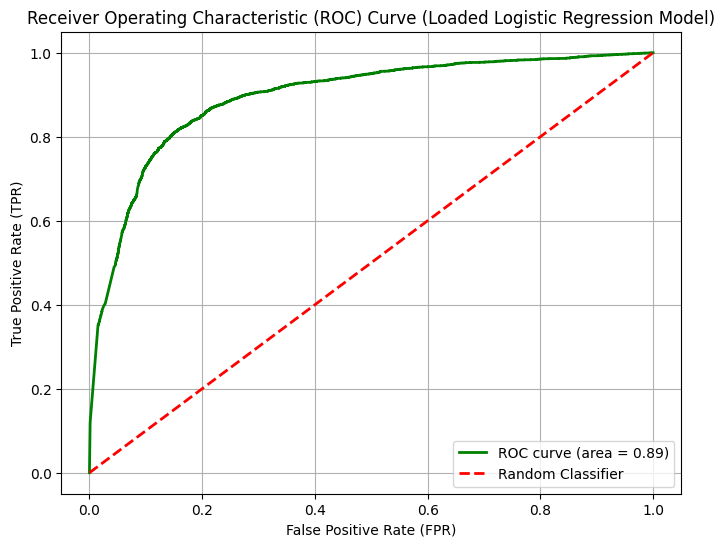

In [16]:
# ROC Curve Plot (Logistic Regression)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba_lr_final):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Loaded Logistic Regression Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization (Logistic Regression) ---



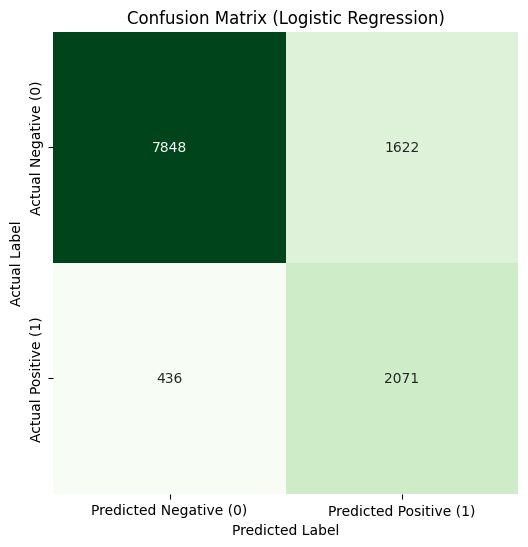

In [17]:
# Confusion Matrix Visualization (Logistic Regression)
print("\n--- Confusion Matrix Visualization (Logistic Regression) ---\n")
cm_lr = confusion_matrix(y_test, y_pred_lr_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

In [18]:
# --- Prediction Results Table (Logistic Regression) ---
results_df_lr = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn_LR': y_pred_lr_final,
    'Predicted_Probability_Churn_LR': y_pred_proba_lr_final
})

print("\n--- Prediction Results Table (Logistic Regression) ---")
print(results_df_lr)


--- Prediction Results Table (Logistic Regression) ---
       True_Churn  Predicted_Churn_LR  Predicted_Probability_Churn_LR
0               0                   0                        0.336533
1               0                   0                        0.274609
2               0                   0                        0.121694
3               0                   1                        0.551052
4               1                   1                        0.949812
...           ...                 ...                             ...
11972           0                   0                        0.026302
11973           0                   0                        0.183319
11974           1                   1                        0.949812
11975           0                   0                        0.062032
11976           0                   0                        0.247051

[11977 rows x 3 columns]


In [19]:
# Find incorrect predictions (Logistic Regression)
incorrect_predictions_lr = results_df_lr[results_df_lr['True_Churn'] != results_df_lr['Predicted_Churn_LR']]

print("\n--- Incorrect Predictions by Logistic Regression Model ---")
print(incorrect_predictions_lr)


--- Incorrect Predictions by Logistic Regression Model ---
       True_Churn  Predicted_Churn_LR  Predicted_Probability_Churn_LR
3               0                   1                        0.551052
5               0                   1                        0.851777
8               1                   0                        0.360479
9               0                   1                        0.702708
22              1                   0                        0.297738
...           ...                 ...                             ...
11910           1                   0                        0.135363
11915           0                   1                        0.732355
11948           0                   1                        0.647200
11963           0                   1                        0.613499
11966           0                   1                        0.576049

[2058 rows x 3 columns]


In [20]:
false_positives_lr = incorrect_predictions_lr[incorrect_predictions_lr['True_Churn'] == 0]
false_negatives_lr = incorrect_predictions_lr[incorrect_predictions_lr['True_Churn'] == 1]

print(f"\nTotal Number of Incorrect Predictions (Logistic Regression): {len(incorrect_predictions_lr)}")
print(f"False Positives (FP) Count (Logistic Regression): {len(false_positives_lr)}")
print(f"False Negatives (FN) Count (Logistic Regression): {len(false_negatives_lr)}")


Total Number of Incorrect Predictions (Logistic Regression): 2058
False Positives (FP) Count (Logistic Regression): 1622
False Negatives (FN) Count (Logistic Regression): 436


In [21]:
# Get model coefficients
lr_coefficients = loaded_lr_model.coef_[0]
features = X.columns

# Convert feature importances to a DataFrame
importance_df_lr = pd.DataFrame({'Feature': features, 'Importance': abs(lr_coefficients)})
importance_df_lr = importance_df_lr.sort_values(by='Importance', ascending=False)

print("\nFeature Importance Scores (Logistic Regression - Absolute Coefficients):\n")
print(importance_df_lr)


Feature Importance Scores (Logistic Regression - Absolute Coefficients):

                                       Feature  Importance
0                                        month    0.659958
6                        user_has_outgoing_sms    0.595094
5                      user_has_outgoing_calls    0.545998
3                    user_account_balance_last    0.514145
13                     calls_outgoing_duration    0.466693
11                        calls_outgoing_count    0.372387
33            last_100_calls_outgoing_duration    0.368774
15                 calls_outgoing_duration_max    0.318053
10                                 reloads_sum    0.306658
21                          sms_outgoing_count    0.284595
35  last_100_calls_outgoing_to_offnet_duration    0.246011
12                    calls_outgoing_spendings    0.245513
9                                reloads_count    0.244372
37                 last_100_sms_outgoing_count    0.234485
18          calls_outgoing_to_offnet_spe

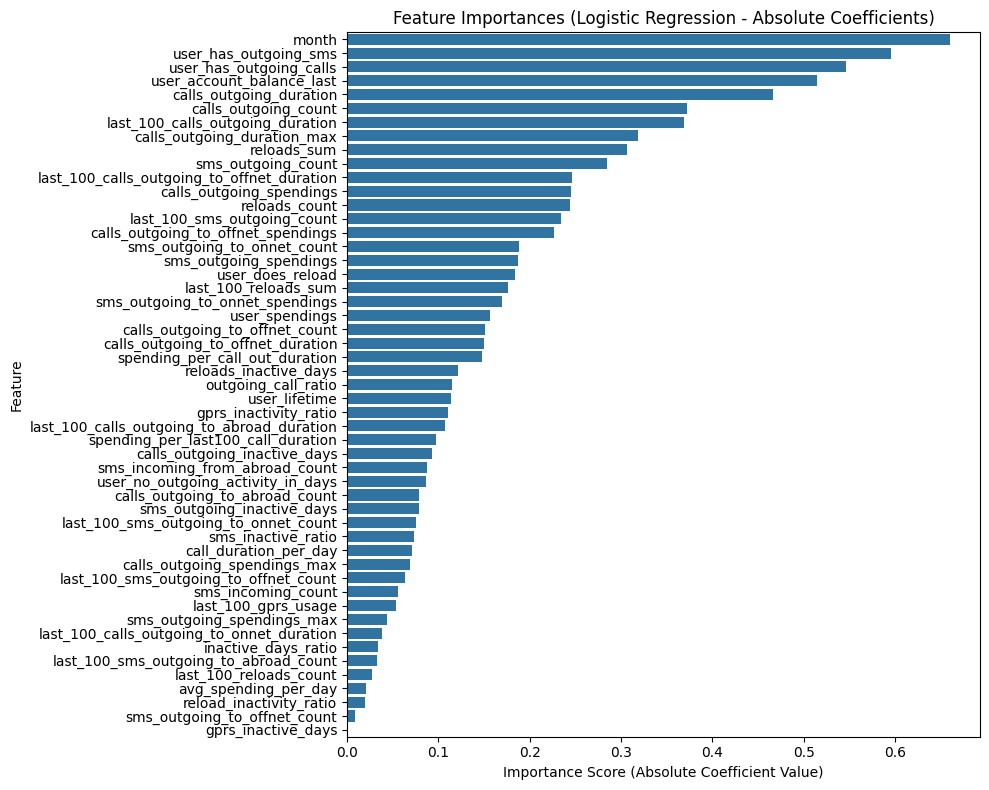

In [22]:
# Feature Importance Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_lr)
plt.title('Feature Importances (Logistic Regression - Absolute Coefficients)')
plt.xlabel('Importance Score (Absolute Coefficient Value)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter grid for XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = ParameterGrid(param_grid_xgb)
best_score_xgb = 0
best_params_xgb = None

print("GridSearch for XGBoost has started...\n")

for params in tqdm(grid_xgb, desc="XGB GridSearch Progress"):
    model_xgb = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    model_xgb.fit(X_train_scaled, y_train_res)
    y_pred_xgb = model_xgb.predict(X_test_scaled)

    score_xgb = f1_score(y_test, y_pred_xgb)
    print(f"Trying parameters: {params} | F1 Score: {score_xgb:.4f}")

    if score_xgb > best_score_xgb:
        best_score_xgb = score_xgb
        best_params_xgb = params

print(f"\nBest Params for XGBoost: {best_params_xgb}")
print(f"Best F1 Score for XGBoost: {best_score_xgb:.4f}")

GridSearch for XGBoost has started...



XGB GridSearch Progress:   6%|▋         | 1/16 [00:01<00:22,  1.49s/it]

Trying parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} | F1 Score: 0.7007


XGB GridSearch Progress:  12%|█▎        | 2/16 [00:02<00:20,  1.44s/it]

Trying parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0} | F1 Score: 0.7005


...

Trying parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0} | F1 Score: 0.7097


XGB GridSearch Progress:  94%|█████████▍| 15/16 [00:47<00:03,  3.42s/it]

Trying parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8} | F1 Score: 0.7102


XGB GridSearch Progress: 100%|██████████| 16/16 [00:53<00:00,  3.33s/it]

Trying parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0} | F1 Score: 0.7093

Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score for XGBoost: 0.7102


In [ ]:
best_params_xgb = {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
final_model_xgb = XGBClassifier(**best_params_xgb, random_state=42, eval_metric='logloss')
final_model_xgb.fit(X_train_scaled, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Save temporarily to Colab's directory
temp_xgb_model_path = os.path.join('/content', XGB_MODEL_FILENAME)
with open(temp_xgb_model_path, 'wb') as file:
    pickle.dump(final_model_xgb, file)
print(f"XGBoost model '{XGB_MODEL_FILENAME}' saved temporarily.")

# Copy the temporary file to Google Drive
shutil.copy(temp_xgb_model_path, os.path.join(DRIVE_MODEL_PATH, XGB_MODEL_FILENAME))
print(f"\nXGBoost model successfully copied to '{DRIVE_MODEL_PATH}' folder.")

XGBoost model 'xgboost_churn_model.pkl' saved temporarily.

XGBoost model successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [23]:
# Full paths of model to be loaded from Google Drive
LOAD_XGB_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, XGB_MODEL_FILENAME)

loaded_xgb_model = None

# Load the XGBoost model
try:
    with open(LOAD_XGB_MODEL_PATH, 'rb') as file:
        loaded_xgb_model = pickle.load(file)
    print(f"XGBoost model loaded successfully from '{LOAD_XGB_MODEL_PATH}'.")
except FileNotFoundError:
    print(f"Error: XGBoost model file '{LOAD_XGB_MODEL_PATH}' not found. Please check the path or train and save the model first.")
except Exception as e:
    print(f"An error occurred while loading the XGBoost model: {e}")

XGBoost model loaded successfully from '/content/drive/MyDrive/machine_learning_models/xgboost_churn_model.pkl'.


In [24]:
# Make predictions using the final XGBoost model
y_pred_xgb_final = loaded_xgb_model.predict(X_test_scaled)
y_pred_proba_xgb_final = loaded_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the final XGBoost model
print("F1 Score (XGB):", f1_score(y_test, y_pred_xgb_final))
print("Accuracy (XGB):", accuracy_score(y_test, y_pred_xgb_final))
print("ROC AUC (XGB):", roc_auc_score(y_test, y_pred_proba_xgb_final))
print("\nClassification Report (XGB):\n", classification_report(y_test, y_pred_xgb_final))
print("\nConfusion Matrix (XGB):\n", confusion_matrix(y_test, y_pred_xgb_final))

F1 Score (XGB): 0.710215931772818
Accuracy (XGB): 0.8666611004425148
ROC AUC (XGB): 0.9090307434852951

Classification Report (XGB):
               precision    recall  f1-score   support

           0       0.94      0.89      0.91      9470
           1       0.65      0.78      0.71      2507

    accuracy                           0.87     11977
   macro avg       0.80      0.84      0.81     11977
weighted avg       0.88      0.87      0.87     11977


Confusion Matrix (XGB):
 [[8423 1047]
 [ 550 1957]]


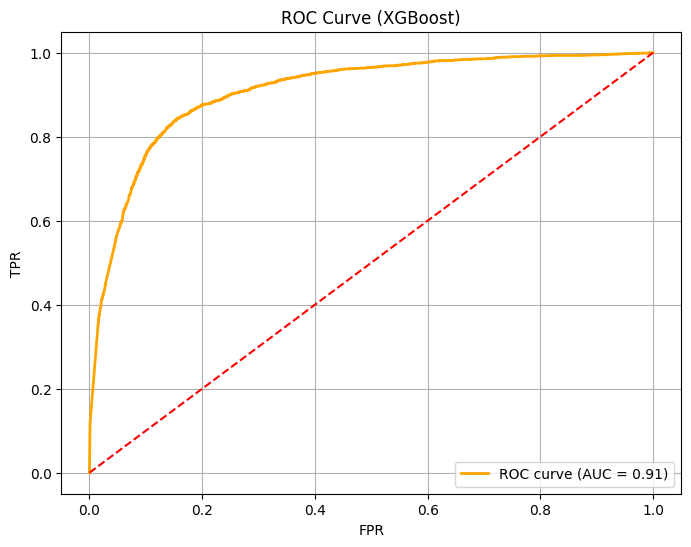

In [25]:
# ROC Curve Plot (XGBoost)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_xgb_final):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve (XGBoost)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization (XGBoost) ---



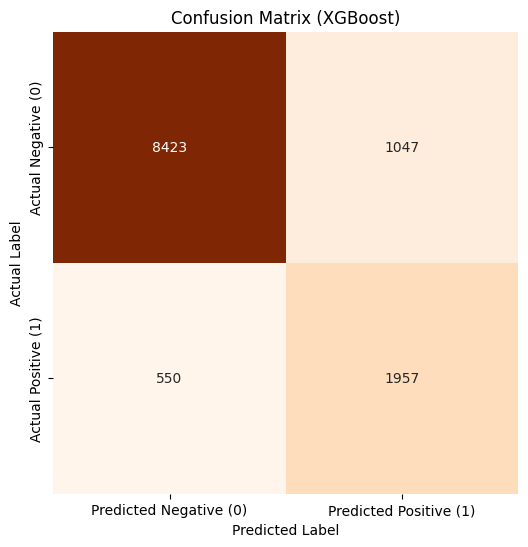

In [26]:
# --- Confusion Matrix Visualization (XGBoost) ---
print("\n--- Confusion Matrix Visualization (XGBoost) ---\n")
cm_xgb = confusion_matrix(y_test, y_pred_xgb_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (XGBoost)')
plt.show()

In [27]:
# --- Prediction Results Table (XGBoost) ---
results_df_xgb = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn_XGB': y_pred_xgb_final,
    'Predicted_Probability_Churn_XGB': y_pred_proba_xgb_final
})

print("\n--- Prediction Results Table (XGBoost) ---")
print(results_df_xgb)


--- Prediction Results Table (XGBoost) ---
       True_Churn  Predicted_Churn_XGB  Predicted_Probability_Churn_XGB
0               0                    0                         0.183317
1               0                    0                         0.339543
2               0                    0                         0.011298
3               0                    0                         0.080725
4               1                    1                         0.992985
...           ...                  ...                              ...
11972           0                    0                         0.011080
11973           0                    0                         0.168563
11974           1                    1                         0.992985
11975           0                    0                         0.017936
11976           0                    0                         0.064947

[11977 rows x 3 columns]


In [28]:
# Find incorrect predictions (XGBoost)
incorrect_predictions_xgb = results_df_xgb[results_df_xgb['True_Churn'] != results_df_xgb['Predicted_Churn_XGB']]

print("\n--- Incorrect Predictions by XGBoost Model ---")
print(incorrect_predictions_xgb)


--- Incorrect Predictions by XGBoost Model ---
       True_Churn  Predicted_Churn_XGB  Predicted_Probability_Churn_XGB
5               0                    1                         0.805707
9               0                    1                         0.564893
22              1                    0                         0.167261
23              1                    0                         0.108562
24              0                    1                         0.850460
...           ...                  ...                              ...
11906           0                    1                         0.850460
11910           1                    0                         0.022036
11915           0                    1                         0.875954
11948           0                    1                         0.536966
11949           0                    1                         0.514072

[1597 rows x 3 columns]


In [29]:
false_positives_xgb = incorrect_predictions_xgb[incorrect_predictions_xgb['True_Churn'] == 0]
false_negatives_xgb = incorrect_predictions_xgb[incorrect_predictions_xgb['True_Churn'] == 1]

print(f"\nTotal Number of Incorrect Predictions (XGBoost): {len(incorrect_predictions_xgb)}")
print(f"False Positives (FP) Count (XGBoost): {len(false_positives_xgb)}")
print(f"False Negatives (FN) Count (XGBoost): {len(false_negatives_xgb)}")


Total Number of Incorrect Predictions (XGBoost): 1597
False Positives (FP) Count (XGBoost): 1047
False Negatives (FN) Count (XGBoost): 550


In [30]:
# Feature Importance Scores (XGBoost)
feature_importances_xgb = loaded_xgb_model.feature_importances_
features = X.columns

# Convert feature importances to DataFrame
importance_df_xgb = pd.DataFrame({'Feature': features, 'Importance': feature_importances_xgb})
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

print("\nFeature Importance Scores (XGBoost):\n")
print(importance_df_xgb)


Feature Importance Scores (XGBoost):

                                       Feature  Importance
4                               user_spendings    0.247467
15                 calls_outgoing_duration_max    0.197607
6                        user_has_outgoing_sms    0.051427
33            last_100_calls_outgoing_duration    0.050610
11                        calls_outgoing_count    0.038062
28                          sms_incoming_count    0.033960
23                  sms_outgoing_spendings_max    0.032098
16                calls_outgoing_inactive_days    0.022652
14                calls_outgoing_spendings_max    0.020995
47                          sms_inactive_ratio    0.018353
2            user_no_outgoing_activity_in_days    0.018146
10                                 reloads_sum    0.017634
26             sms_outgoing_to_onnet_spendings    0.016281
5                      user_has_outgoing_calls    0.015963
7                             user_does_reload    0.014563
45               

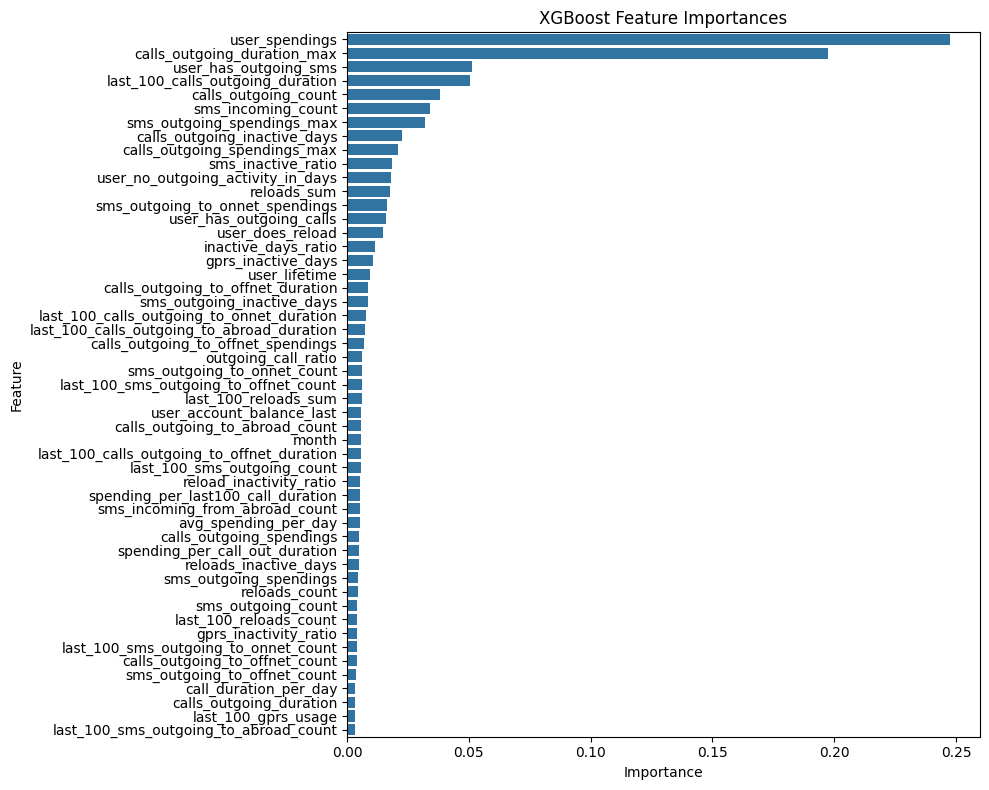

In [31]:
# Feature Importance Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter grid for LinearSVC
param_grid_linear_svc = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'loss': ['squared_hinge'],
    'dual': [False],
    'max_iter': [5000, 10000]
}

grid_linear_svc = ParameterGrid(param_grid_linear_svc)
best_score_linear_svc = 0
best_params_linear_svc = None

print("\nLinearSVC GridSearch Started...\n")

for params in tqdm(grid_linear_svc, desc="LinearSVC GridSearch Progress"):
        model_linear_svc = LinearSVC(**params, random_state=42)
        model_linear_svc.fit(X_train_scaled, y_train_res)
        y_pred_linear_svc = model_linear_svc.predict(X_test_scaled)

        score_linear_svc = f1_score(y_test, y_pred_linear_svc)
        print(f"Trying parameters: {params} | F1 Score: {score_linear_svc:.4f}")

        if score_linear_svc > best_score_linear_svc:
            best_score_linear_svc = score_linear_svc
            best_params_linear_svc = params

print(f"\nBest Params for LinearSVC: {best_params_linear_svc}")
print(f"Best F1 Score for LinearSVC: {best_score_linear_svc:.4f}")


LinearSVC GridSearch Started...



LinearSVC GridSearch Progress:   8%|▊         | 1/12 [00:09<01:45,  9.62s/it]

Trying parameters: {'C': 0.1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000, 'penalty': 'l1'} | F1 Score: 0.6681


LinearSVC GridSearch Progress:  17%|█▋        | 2/12 [00:11<00:49,  4.99s/it]

Trying parameters: {'C': 0.1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000, 'penalty': 'l2'} | F1 Score: 0.6680


...

Trying parameters: {'C': 10, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000, 'penalty': 'l2'} | F1 Score: 0.6679


LinearSVC GridSearch Progress:  92%|█████████▏| 11/12 [01:01<00:05,  5.99s/it]

Trying parameters: {'C': 10, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 10000, 'penalty': 'l1'} | F1 Score: 0.6679


LinearSVC GridSearch Progress: 100%|██████████| 12/12 [01:03<00:00,  5.27s/it]

Trying parameters: {'C': 10, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 10000, 'penalty': 'l2'} | F1 Score: 0.6679

Best Params for LinearSVC: {'C': 0.1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000, 'penalty': 'l1'}
Best F1 Score for LinearSVC: 0.6681


In [ ]:
best_params_linear_svc = {'C': 0.1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000, 'penalty': 'l1'}
final_model_linear_svc = LinearSVC(**best_params_linear_svc, random_state=42)
final_model_linear_svc.fit(X_train_scaled, y_train_res)

LinearSVC(C=0.1, dual=False, max_iter=5000, penalty='l1', random_state=42)

In [ ]:
# First save to Colab's temporary directory
temp_linear_svc_model_path = os.path.join('/content', LINEAR_SVC_MODEL_FILENAME)
with open(temp_linear_svc_model_path, 'wb') as file:
    pickle.dump(final_model_linear_svc, file)
print(f"LinearSVC model '{LINEAR_SVC_MODEL_FILENAME}' temporarily saved.")

# Copy the temporary file to Google Drive
shutil.copy(temp_linear_svc_model_path, os.path.join(DRIVE_MODEL_PATH, LINEAR_SVC_MODEL_FILENAME))
print(f"\nLinearSVC model successfully copied to '{DRIVE_MODEL_PATH}' folder.")

LinearSVC model 'linear_svc_churn_model.pkl' temporarily saved.

LinearSVC model successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [32]:
# Full paths of model to be loaded from Google Drive
LOAD_LINEAR_SVC_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, LINEAR_SVC_MODEL_FILENAME)

loaded_linear_svc_model = None

# Load the LinearSVC model
try:
    with open(LOAD_LINEAR_SVC_MODEL_PATH, 'rb') as file:
        loaded_linear_svc_model = pickle.load(file)
    print(f"LinearSVC model loaded successfully from '{LOAD_LINEAR_SVC_MODEL_PATH}'.")
except FileNotFoundError:
    print(f"Error: LinearSVC model file '{LOAD_LINEAR_SVC_MODEL_PATH}' not found. Please check the path or train and save the model first.")
except Exception as e:
    print(f"An error occurred while loading the LinearSVC model: {e}")

LinearSVC model loaded successfully from '/content/drive/MyDrive/machine_learning_models/linear_svc_churn_model.pkl'.


In [33]:
from sklearn.calibration import CalibratedClassifierCV

y_pred_linear_svc_final = loaded_linear_svc_model.predict(X_test_scaled)

calibrated_linear_svc = CalibratedClassifierCV(loaded_linear_svc_model, method='sigmoid', cv='prefit')
calibrated_linear_svc.fit(X_train_scaled, y_train_res)
y_pred_proba_linear_svc_final_calibrated = calibrated_linear_svc.predict_proba(X_test_scaled)[:, 1]

print("F1 Score (LinearSVC):", f1_score(y_test, y_pred_linear_svc_final))
print("Accuracy (LinearSVC):", accuracy_score(y_test, y_pred_linear_svc_final))
print("ROC AUC (LinearSVC):", roc_auc_score(y_test, y_pred_proba_linear_svc_final_calibrated))
print("\nClassification Report (LinearSVC):\n", classification_report(y_test, y_pred_linear_svc_final))
print("\nConfusion Matrix (LinearSVC):\n", confusion_matrix(y_test, y_pred_linear_svc_final))


/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


F1 Score (LinearSVC): 0.6680692668716621
Accuracy (LinearSVC): 0.8287551139684395
ROC AUC (LinearSVC): 0.893541168150509

Classification Report (LinearSVC):
               precision    recall  f1-score   support

           0       0.95      0.83      0.88      9470
           1       0.56      0.82      0.67      2507

    accuracy                           0.83     11977
   macro avg       0.75      0.83      0.78     11977
weighted avg       0.87      0.83      0.84     11977


Confusion Matrix (LinearSVC):
 [[7862 1608]
 [ 443 2064]]


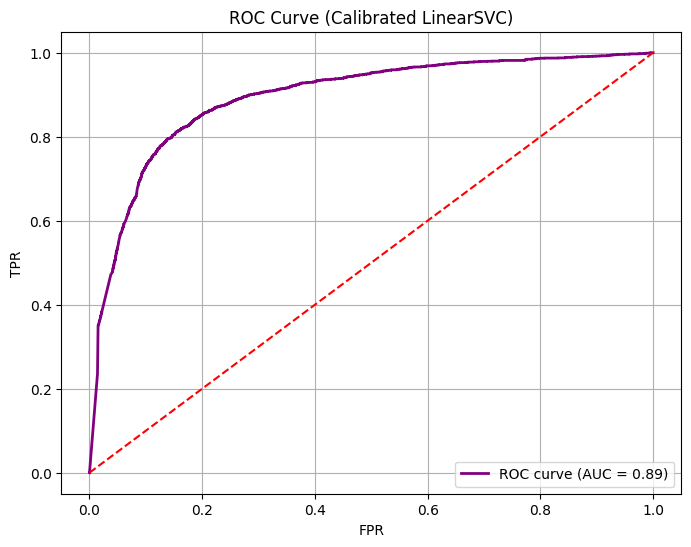

In [34]:
# ROC Curve Plot (Calibrated LinearSVC)
fpr_linear_svc_calibrated, tpr_linear_svc_calibrated, _ = roc_curve(y_test, y_pred_proba_linear_svc_final_calibrated)
plt.figure(figsize=(8, 6))
plt.plot(fpr_linear_svc_calibrated, tpr_linear_svc_calibrated, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_linear_svc_final_calibrated):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve (Calibrated LinearSVC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization (LinearSVC) ---



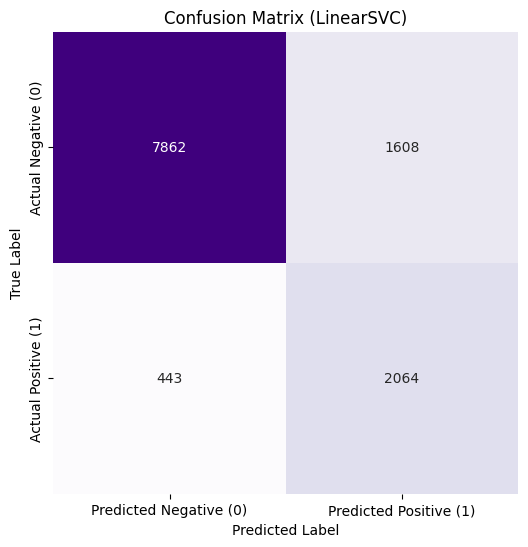

In [35]:
# --- Confusion Matrix Visualization (LinearSVC) ---
print("\n--- Confusion Matrix Visualization (LinearSVC) ---\n")
cm_linear_svc = confusion_matrix(y_test, y_pred_linear_svc_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_linear_svc, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (LinearSVC)')
plt.show()

In [36]:
# --- Prediction Results Table (LinearSVC) ---
results_df_linear_svc = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn_LinearSVC': y_pred_linear_svc_final,
    'Predicted_Probability_Churn_LinearSVC': y_pred_proba_linear_svc_final_calibrated
})

print("\n--- Prediction Results Table (LinearSVC) ---\n")
print(results_df_linear_svc)


--- Prediction Results Table (LinearSVC) ---

       True_Churn  Predicted_Churn_LinearSVC  \
0               0                          0   
1               0                          0   
2               0                          0   
3               0                          1   
4               1                          1   
...           ...                        ...   
11972           0                          0   
11973           0                          0   
11974           1                          1   
11975           0                          0   
11976           0                          0   

       Predicted_Probability_Churn_LinearSVC  
0                                   0.359060  
1                                   0.241065  
2                                   0.134217  
3                                   0.544561  
4                                   0.929772  
...                                      ...  
11972                               0.033611  


In [37]:
# Find incorrect predictions (LinearSVC)
incorrect_predictions_linear_svc = results_df_linear_svc[results_df_linear_svc['True_Churn'] != results_df_linear_svc['Predicted_Churn_LinearSVC']]

print("\n--- Misclassified Rows by LinearSVC Model ---")
print(incorrect_predictions_linear_svc)


--- Misclassified Rows by LinearSVC Model ---
       True_Churn  Predicted_Churn_LinearSVC  \
3               0                          1   
5               0                          1   
8               1                          0   
9               0                          1   
22              1                          0   
...           ...                        ...   
11910           1                          0   
11915           0                          1   
11948           0                          1   
11963           0                          1   
11966           0                          1   

       Predicted_Probability_Churn_LinearSVC  
3                                   0.544561  
5                                   0.877478  
8                                   0.380225  
9                                   0.730988  
22                                  0.264481  
...                                      ...  
11910                               0.139363  


In [38]:
false_positives_linear_svc = incorrect_predictions_linear_svc[incorrect_predictions_linear_svc['True_Churn'] == 0]
false_negatives_linear_svc = incorrect_predictions_linear_svc[incorrect_predictions_linear_svc['True_Churn'] == 1]

print(f"\nTotal Misclassified Samples (LinearSVC): {len(incorrect_predictions_linear_svc)}")
print(f"False Positives (FP) Count (LinearSVC): {len(false_positives_linear_svc)}")
print(f"False Negatives (FN) Count (LinearSVC): {len(false_negatives_linear_svc)}")


Total Misclassified Samples (LinearSVC): 2051
False Positives (FP) Count (LinearSVC): 1608
False Negatives (FN) Count (LinearSVC): 443


In [39]:
# Feature Importance Scores and Visualization (LinearSVC)
linear_svc_coefficients = loaded_linear_svc_model.coef_[0]
features = X.columns

importance_df_linear_svc = pd.DataFrame({'Feature': features, 'Importance': abs(linear_svc_coefficients)})
importance_df_linear_svc = importance_df_linear_svc.sort_values(by='Importance', ascending=False)

print("\nFeature Importance Scores (LinearSVC - Absolute Coefficients):\n")
print(importance_df_linear_svc)


Feature Importance Scores (LinearSVC - Absolute Coefficients):

                                       Feature  Importance
6                        user_has_outgoing_sms    0.233496
0                                        month    0.229778
5                      user_has_outgoing_calls    0.224922
3                    user_account_balance_last    0.172031
10                                 reloads_sum    0.113563
13                     calls_outgoing_duration    0.110149
33            last_100_calls_outgoing_duration    0.093517
11                        calls_outgoing_count    0.087774
15                 calls_outgoing_duration_max    0.085428
21                          sms_outgoing_count    0.074248
7                             user_does_reload    0.074055
12                    calls_outgoing_spendings    0.071691
16                calls_outgoing_inactive_days    0.064178
35  last_100_calls_outgoing_to_offnet_duration    0.057773
1                                user_lifetime    

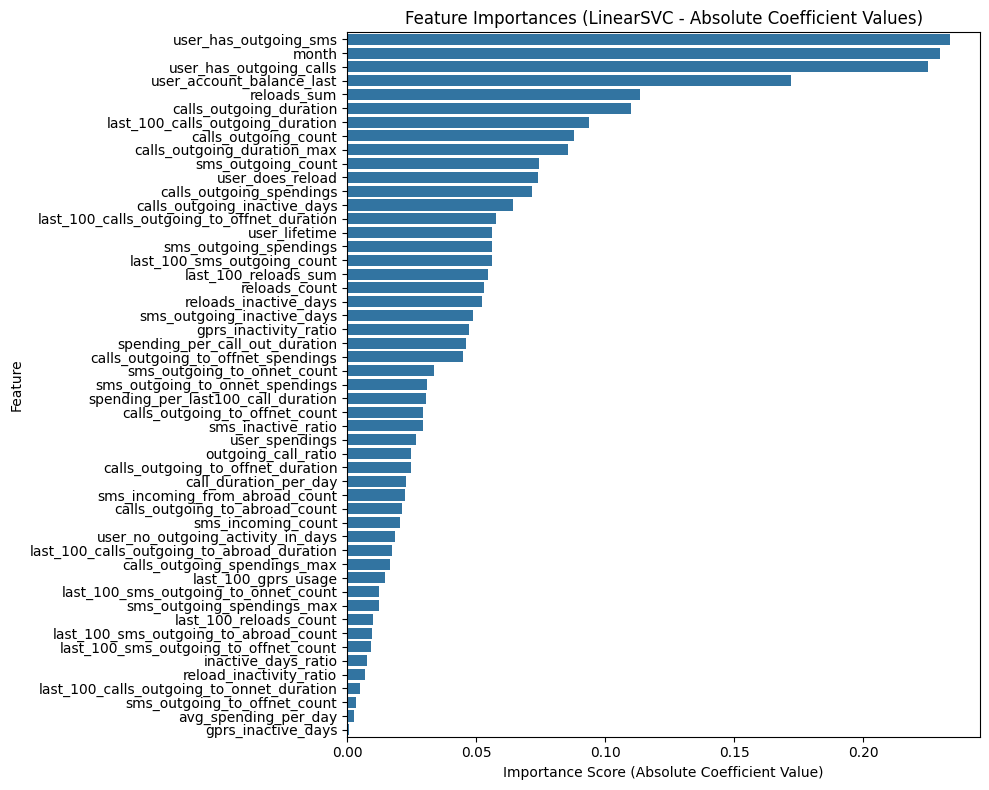

In [40]:
# Feature Importance Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_linear_svc)
plt.title('Feature Importances (LinearSVC - Absolute Coefficient Values)')
plt.xlabel('Importance Score (Absolute Coefficient Value)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter grid for KNeighborsClassifier
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = ParameterGrid(param_grid_knn)
best_score_knn = 0
best_params_knn = None

print("\nKNeighborsClassifier GridSearch Started...\n")

for params in tqdm(grid_knn, desc="KNN GridSearch Progress"):
    model_knn = KNeighborsClassifier(**params)
    model_knn.fit(X_train_scaled, y_train_res)
    y_pred_knn = model_knn.predict(X_test_scaled)

    score_knn = f1_score(y_test, y_pred_knn)
    print(f"Trying parameters: {params} | F1 Score: {score_knn:.4f}")

    if score_knn > best_score_knn:
            best_score_knn = score_knn
            best_params_knn = params

print(f"\nBest Params for KNN: {best_params_knn}")
print(f"Best F1 Score for KNN: {best_score_knn:.4f}")


KNeighborsClassifier GridSearch Started...



KNN GridSearch Progress:   6%|▋         | 1/16 [00:08<02:03,  8.21s/it]

Trying parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'} | F1 Score: 0.6195


KNN GridSearch Progress:  12%|█▎        | 2/16 [00:15<01:45,  7.54s/it]

Trying parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} | F1 Score: 0.6150


...

Trying parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'} | F1 Score: 0.6090


KNN GridSearch Progress:  94%|█████████▍| 15/16 [07:35<00:52, 52.54s/it]

Trying parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'} | F1 Score: 0.6574


KNN GridSearch Progress: 100%|██████████| 16/16 [08:31<00:00, 31.99s/it]

Trying parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} | F1 Score: 0.6510

Best Params for KNN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best F1 Score for KNN: 0.6574


In [ ]:
best_params_knn = {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
final_model_knn = KNeighborsClassifier(**best_params_knn)
final_model_knn.fit(X_train_scaled, y_train_res)

KNeighborsClassifier(metric='manhattan', n_neighbors=9)

In [ ]:
# Save temporarily to Colab's directory
temp_knn_model_path = os.path.join('/content', KNN_MODEL_FILENAME)
with open(temp_knn_model_path, 'wb') as file:
    pickle.dump(final_model_knn, file)
print(f"KNN model '{KNN_MODEL_FILENAME}' temporarily saved.")

# Copy the temporary file to Google Drive
shutil.copy(temp_knn_model_path, os.path.join(DRIVE_MODEL_PATH, KNN_MODEL_FILENAME))
print(f"\nKNN model successfully copied to '{DRIVE_MODEL_PATH}' folder.")

KNN model 'knn_churn_model.pkl' temporarily saved.

KNN model successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [41]:
# Full paths of model to be loaded from Google Drive
LOAD_KNN_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, KNN_MODEL_FILENAME)

loaded_knn_model = None

# Load the KNN model
try:
    with open(LOAD_KNN_MODEL_PATH, 'rb') as file:
        loaded_knn_model = pickle.load(file)
    print(f"KNN model loaded successfully from '{LOAD_KNN_MODEL_PATH}'.")
except FileNotFoundError:
    print(f"Error: KNN model file '{LOAD_KNN_MODEL_PATH}' not found. Please check the path or train and save the model first.")
except Exception as e:
    print(f"An error occurred while loading the KNN model: {e}")

KNN model loaded successfully from '/content/drive/MyDrive/machine_learning_models/knn_churn_model.pkl'.


In [42]:
# Make predictions with the final KNN model
y_pred_knn_final = loaded_knn_model.predict(X_test_scaled)
y_pred_proba_knn_final = loaded_knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the final KNN model
print("F1 Score (KNN):", f1_score(y_test, y_pred_knn_final))
print("Accuracy (KNN):", accuracy_score(y_test, y_pred_knn_final))
print("ROC AUC (KNN):", roc_auc_score(y_test, y_pred_proba_knn_final))
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn_final))
print("\nConfusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn_final))

F1 Score (KNN): 0.6574464496542418
Accuracy (KNN): 0.8304249812139934
ROC AUC (KNN): 0.8746647296755989

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.93      0.84      0.89      9470
           1       0.57      0.78      0.66      2507

    accuracy                           0.83     11977
   macro avg       0.75      0.81      0.77     11977
weighted avg       0.86      0.83      0.84     11977


Confusion Matrix (KNN):
 [[7997 1473]
 [ 558 1949]]


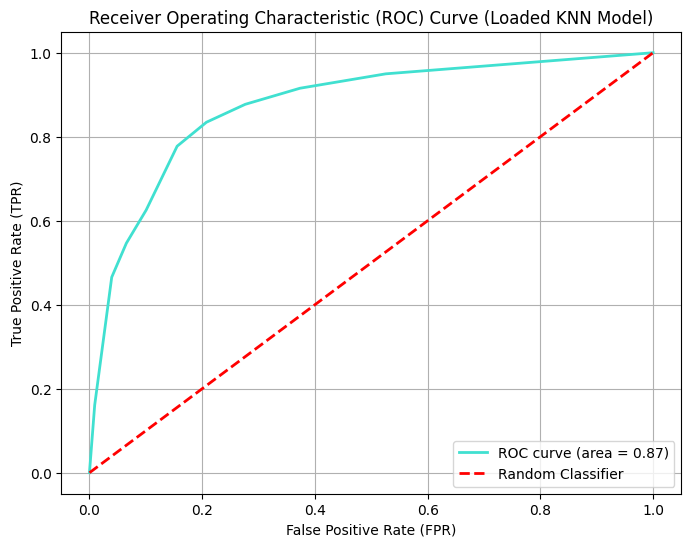

In [43]:
# --- ROC Curve Plot (KNN) ---
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='Turquoise', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba_knn_final):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Loaded KNN Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization (KNN) ---



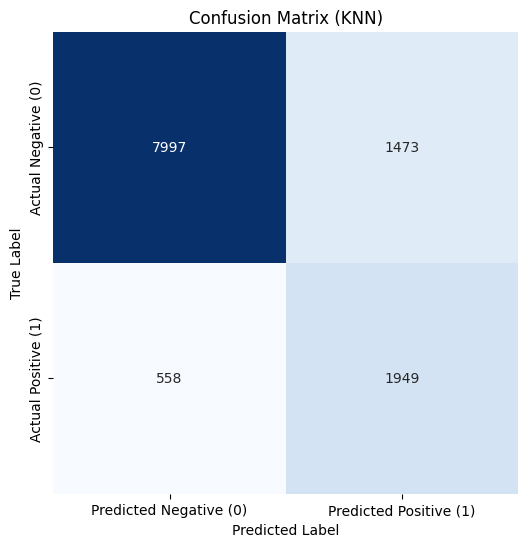

In [44]:
# --- Confusion Matrix Visualization (KNN) ---
print("\n--- Confusion Matrix Visualization (KNN) ---\n")
cm_knn = confusion_matrix(y_test, y_pred_knn_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (KNN)')
plt.show()

In [45]:
# --- Prediction Results Table (KNN) ---
results_df_knn = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn_KNN': y_pred_knn_final,
    'Predicted_Probability_Churn_KNN': y_pred_proba_knn_final
})

print("\n--- Prediction Results Table (KNN) ---")
print(results_df_knn)


--- Prediction Results Table (KNN) ---
       True_Churn  Predicted_Churn_KNN  Predicted_Probability_Churn_KNN
0               0                    0                         0.222222
1               0                    0                         0.111111
2               0                    0                         0.111111
3               0                    0                         0.000000
4               1                    1                         1.000000
...           ...                  ...                              ...
11972           0                    0                         0.000000
11973           0                    0                         0.000000
11974           1                    1                         1.000000
11975           0                    0                         0.222222
11976           0                    0                         0.222222

[11977 rows x 3 columns]


In [46]:
# Find misclassified predictions (KNN)
incorrect_predictions_knn = results_df_knn[results_df_knn['True_Churn'] != results_df_knn['Predicted_Churn_KNN']]

print("\n--- Misclassified Rows by KNN Model ---")
print(incorrect_predictions_knn)


--- Misclassified Rows by KNN Model ---
       True_Churn  Predicted_Churn_KNN  Predicted_Probability_Churn_KNN
5               0                    1                         1.000000
8               1                    0                         0.444444
9               0                    1                         1.000000
22              1                    0                         0.444444
23              1                    0                         0.333333
...           ...                  ...                              ...
11924           0                    1                         0.666667
11927           0                    1                         0.666667
11948           0                    1                         0.555556
11949           0                    1                         0.777778
11963           0                    1                         0.666667

[2031 rows x 3 columns]


In [47]:
false_positives_knn = incorrect_predictions_knn[incorrect_predictions_knn['True_Churn'] == 0]
false_negatives_knn = incorrect_predictions_knn[incorrect_predictions_knn['True_Churn'] == 1]

print(f"\nTotal Misclassified Samples (KNN): {len(incorrect_predictions_knn)}")
print(f"False Positives (FP) Count (KNN): {len(false_positives_knn)}")
print(f"False Negatives (FN) Count (KNN): {len(false_negatives_knn)}")


Total Misclassified Samples (KNN): 2031
False Positives (FP) Count (KNN): 1473
False Negatives (FN) Count (KNN): 558


In [53]:
from sklearn.inspection import permutation_importance
import numpy as np

subset_size = min(1000, X_test_scaled.shape[0])

indices = np.random.choice(X_test_scaled.shape[0], subset_size, replace=False)
X_test_scaled_subset = X_test_scaled[indices]
y_test_subset = y_test.iloc[indices]

print(f"A subset of {subset_size} test samples is used for permutation importance calculation.")

perm_importance_knn = permutation_importance(
    loaded_knn_model,
    X_test_scaled_subset,
    y_test_subset,
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

importance_df_knn_perm = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance_knn.importances_mean,
    'Std_Dev': perm_importance_knn.importances_std
})

# Sort by importance scores
importance_df_knn_perm = importance_df_knn_perm.sort_values(by='Importance', ascending=False)
print(importance_df_knn_perm)

A subset of 1000 test samples is used for permutation importance calculation.
                                       Feature  Importance  Std_Dev
6                        user_has_outgoing_sms      0.0155   0.0025
5                      user_has_outgoing_calls      0.0125   0.0025
28                          sms_incoming_count      0.0100   0.0050
7                             user_does_reload      0.0060   0.0020
37                 last_100_sms_outgoing_count      0.0055   0.0015
10                                 reloads_sum      0.0050   0.0000
3                    user_account_balance_last      0.0050   0.0020
30                          gprs_inactive_days      0.0035   0.0025
39       last_100_sms_outgoing_to_offnet_count      0.0035   0.0005
16                calls_outgoing_inactive_days      0.0025   0.0005
0                                        month      0.0020   0.0000
9                                reloads_count      0.0020   0.0020
32                        last_100_rel

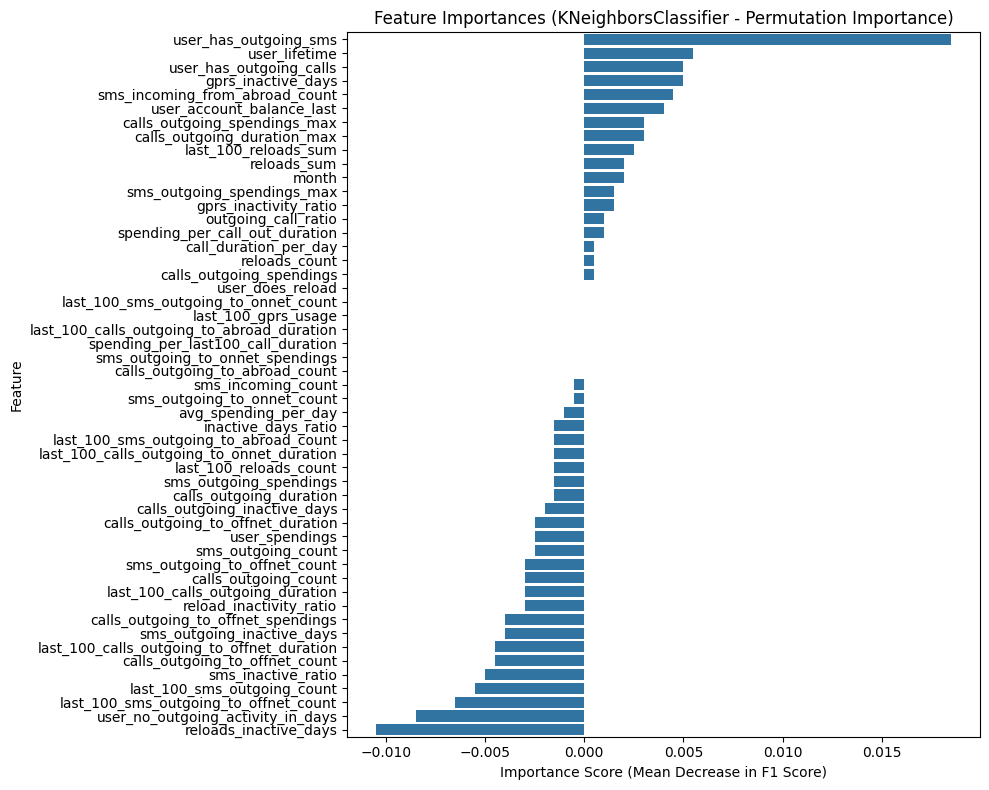

In [49]:
# Feature Importance Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_knn_perm)
plt.title('Feature Importances (KNeighborsClassifier - Permutation Importance)')
plt.xlabel('Importance Score (Mean Decrease in F1 Score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter grid for MLPClassifier
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'max_iter': [500]
}

grid_mlp = ParameterGrid(param_grid_mlp)
best_score_mlp = 0
best_params_mlp = None

print("\nMLPClassifier GridSearch Started...\n")

for params in tqdm(grid_mlp, desc="MLP GridSearch Progress"):
    model_mlp = MLPClassifier(**params, random_state=42)
    model_mlp.fit(X_train_scaled, y_train_res)
    y_pred_mlp = model_mlp.predict(X_test_scaled)

    score_mlp = f1_score(y_test, y_pred_mlp)
    print(f"Trying parameters: {params} | F1 Score: {score_mlp:.4f}")

    if score_mlp > best_score_mlp:
            best_score_mlp = score_mlp
            best_params_mlp = params

print(f"\nBest Params for MLPClassifier: {best_params_mlp}")
print(f"Best F1 Score for MLPClassifier: {best_score_mlp:.4f}")


MLPClassifier GridSearch Started...



MLP GridSearch Progress:  12%|█▎        | 1/8 [01:40<11:42, 100.36s/it]

Trying parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'} | F1 Score: 0.6783


MLP GridSearch Progress:  25%|██▌       | 2/8 [04:03<12:32, 125.37s/it]

Trying parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 500, 'solver': 'adam'} | F1 Score: 0.6609


...

Trying parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 500, 'solver': 'adam'} | F1 Score: 0.6621


MLP GridSearch Progress:  88%|████████▊ | 7/8 [22:10<03:59, 239.71s/it]

Trying parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'} | F1 Score: 0.6624


MLP GridSearch Progress: 100%|██████████| 8/8 [28:45<00:00, 215.74s/it]

Trying parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 500, 'solver': 'adam'} | F1 Score: 0.6675

Best Params for MLPClassifier: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'}
Best F1 Score for MLPClassifier: 0.6794


In [ ]:
best_params_mlp = {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'}
final_model_mlp = MLPClassifier(**best_params_mlp, random_state=42)
final_model_mlp.fit(X_train_scaled, y_train_res)

MLPClassifier(alpha=0.001, hidden_layer_sizes=(50,), max_iter=500,
              random_state=42)

In [ ]:
# Save temporarily to Colab's directory
temp_mlp_model_path = os.path.join('/content', MLP_MODEL_FILENAME)
with open(temp_mlp_model_path, 'wb') as file:
    pickle.dump(final_model_mlp, file)
print(f"MLPClassifier model '{MLP_MODEL_FILENAME}' temporarily saved.")

# Copy the temporary file to Google Drive
shutil.copy(temp_mlp_model_path, os.path.join(DRIVE_MODEL_PATH, MLP_MODEL_FILENAME))
print(f"\nMLPClassifier model successfully copied to '{DRIVE_MODEL_PATH}' folder.")

MLPClassifier model 'mlp_churn_model.pkl' temporarily saved.

MLPClassifier model successfully copied to '/content/drive/MyDrive/machine_learning_models' folder.


In [54]:
# Full paths of model to be loaded from Google Drive
LOAD_MLP_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, MLP_MODEL_FILENAME)

loaded_mlp_model = None

# Load the MLPClassifier model
try:
    with open(LOAD_MLP_MODEL_PATH, 'rb') as file:
        loaded_mlp_model = pickle.load(file)
    print(f"MLPClassifier model loaded successfully from '{LOAD_MLP_MODEL_PATH}'.")
except FileNotFoundError:
    print(f"Error: MLPClassifier model file '{LOAD_MLP_MODEL_PATH}' not found. Please check the path or train and save the model first.")
except Exception as e:
    print(f"An error occurred while loading the MLPClassifier model: {e}")

MLPClassifier model loaded successfully from '/content/drive/MyDrive/machine_learning_models/mlp_churn_model.pkl'.


In [55]:
y_pred_mlp_final = loaded_mlp_model.predict(X_test_scaled)
y_pred_proba_mlp_final = loaded_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the final MLPClassifier model
print("F1 Score (MLP):", f1_score(y_test, y_pred_mlp_final))
print("Accuracy (MLP):", accuracy_score(y_test, y_pred_mlp_final))
print("ROC AUC (MLP):", roc_auc_score(y_test, y_pred_proba_mlp_final))
print("\nClassification Report (MLP):\n", classification_report(y_test, y_pred_mlp_final))
print("\nConfusion Matrix (MLP):\n", confusion_matrix(y_test, y_pred_mlp_final))

F1 Score (MLP): 0.6793514228987425
Accuracy (MLP): 0.8381898639058195
ROC AUC (MLP): 0.8903311277525356

Classification Report (MLP):
               precision    recall  f1-score   support

           0       0.95      0.84      0.89      9470
           1       0.58      0.82      0.68      2507

    accuracy                           0.84     11977
   macro avg       0.76      0.83      0.79     11977
weighted avg       0.87      0.84      0.85     11977


Confusion Matrix (MLP):
 [[7986 1484]
 [ 454 2053]]


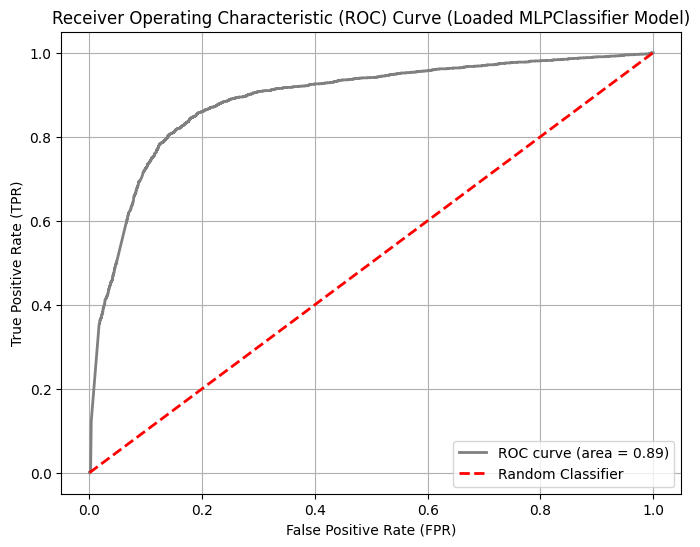

In [56]:
# --- ROC Curve Plot (MLP) ---
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_pred_proba_mlp_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, color='gray', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba_mlp_final):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Loaded MLPClassifier Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


--- Confusion Matrix Visualization (MLP) ---



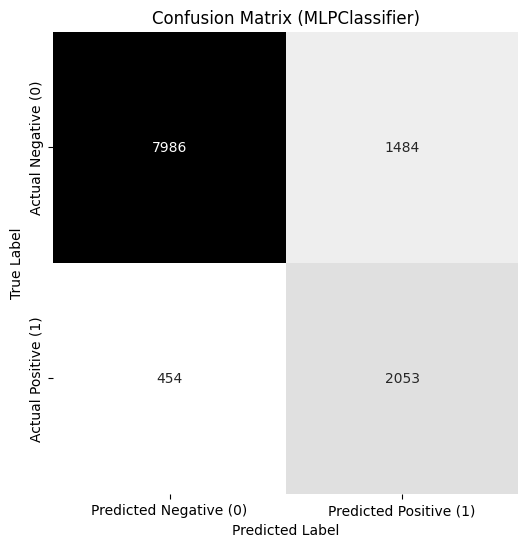

In [57]:
# --- Confusion Matrix Visualization (MLP) ---
print("\n--- Confusion Matrix Visualization (MLP) ---\n")
cm_mlp = confusion_matrix(y_test, y_pred_mlp_final)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Grays', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (MLPClassifier)')
plt.show()

In [58]:
# --- Prediction Results Table (MLP) ---
results_df_mlp = pd.DataFrame({
    'True_Churn': y_test.values,
    'Predicted_Churn_MLP': y_pred_mlp_final,
    'Predicted_Probability_Churn_MLP': y_pred_proba_mlp_final
})

print("\n--- Prediction Results Table (MLP) ---")
print(results_df_mlp)


--- Prediction Results Table (MLP) ---
       True_Churn  Predicted_Churn_MLP  Predicted_Probability_Churn_MLP
0               0                    0                         0.061613
1               0                    0                         0.111773
2               0                    0                         0.000313
3               0                    0                         0.017564
4               1                    1                         0.976703
...           ...                  ...                              ...
11972           0                    0                         0.001440
11973           0                    0                         0.007798
11974           1                    1                         0.976703
11975           0                    0                         0.000528
11976           0                    0                         0.088881

[11977 rows x 3 columns]


In [59]:
# Find misclassified predictions (MLP)
incorrect_predictions_mlp = results_df_mlp[results_df_mlp['True_Churn'] != results_df_mlp['Predicted_Churn_MLP']]

print("\n--- Misclassified Rows by MLPClassifier Model ---")
print(incorrect_predictions_mlp)


--- Misclassified Rows by MLPClassifier Model ---
       True_Churn  Predicted_Churn_MLP  Predicted_Probability_Churn_MLP
5               0                    1                         0.853576
8               1                    0                         0.020159
9               0                    1                         0.822410
22              1                    0                         0.100795
24              0                    1                         0.815017
...           ...                  ...                              ...
11915           0                    1                         0.900215
11927           0                    1                         0.585648
11948           0                    1                         0.619639
11949           0                    1                         0.566186
11965           0                    1                         0.601709

[1938 rows x 3 columns]


In [60]:
false_positives_mlp = incorrect_predictions_mlp[incorrect_predictions_mlp['True_Churn'] == 0]
false_negatives_mlp = incorrect_predictions_mlp[incorrect_predictions_mlp['True_Churn'] == 1]

print(f"\nTotal Misclassified Samples (MLP): {len(incorrect_predictions_mlp)}")
print(f"False Positives (FP) Count (MLP): {len(false_positives_mlp)}")
print(f"False Negatives (FN) Count (MLP): {len(false_negatives_mlp)}")


Total Misclassified Samples (MLP): 1938
False Positives (FP) Count (MLP): 1484
False Negatives (FN) Count (MLP): 454


In [61]:
import shap

# Sample 100 points from training data as background for SHAP
background_data = shap.utils.sample(X_train_scaled, 100)

# Sample up to 500 points from test set to speed up SHAP calculation
sample_size_for_shap = min(2000, X_test_scaled.shape[0])
X_test_scaled_sample = shap.utils.sample(X_test_scaled, sample_size_for_shap, random_state=42)

# Initialize SHAP explainer with MLP's predict_proba and background data
explainer_mlp = shap.KernelExplainer(loaded_mlp_model.predict_proba, background_data)

print(f"Calculating SHAP values on {sample_size_for_shap}")
shap_explanation_mlp = explainer_mlp(X_test_scaled_sample)
print("SHAP values calculated.")

# Get SHAP values for class 1
shap_values_for_class_1 = shap_explanation_mlp.values[:, :, 1]

shap_df_mlp = pd.DataFrame(shap_values_for_class_1, columns=X.columns)
mean_abs_shap_values_mlp = shap_df_mlp.abs().mean().sort_values(ascending=False)

print("\nSHAP Feature Importance Scores (MLPClassifier - Mean |SHAP|):\n")
print(mean_abs_shap_values_mlp)

Calculating SHAP values on 2000


  0%|          | 0/2000 [00:00<?, ?it/s]

SHAP values calculated.

SHAP Feature Importance Scores (MLPClassifier - Mean |SHAP|):

user_does_reload                              0.145256
user_has_outgoing_sms                         0.098419
reloads_sum                                   0.068584
user_has_outgoing_calls                       0.056764
user_lifetime                                 0.042893
reloads_inactive_days                         0.035452
sms_outgoing_to_onnet_count                   0.033158
calls_outgoing_count                          0.027992
last_100_calls_outgoing_duration              0.025254
calls_outgoing_to_offnet_count                0.022667
sms_outgoing_to_onnet_spendings               0.021927
last_100_sms_outgoing_to_offnet_count         0.020940
month                                         0.016341
last_100_reloads_sum                          0.014848
sms_outgoing_spendings_max                    0.014157
user_spendings                                0.013061
last_100_sms_outgoing_count     

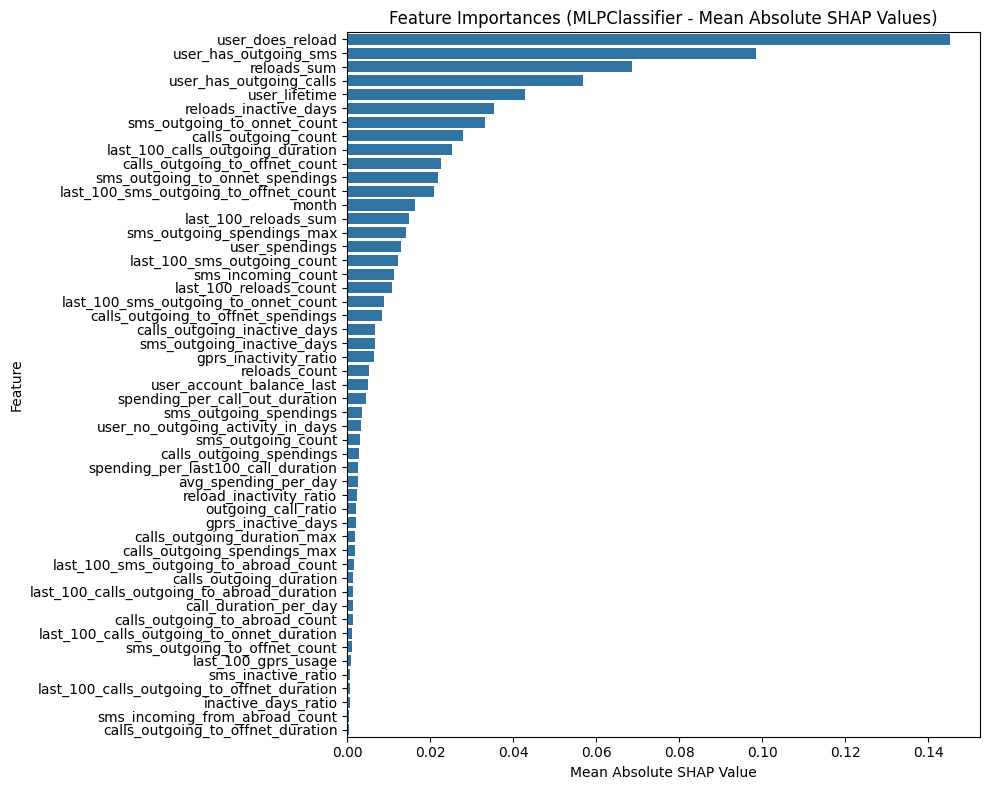

In [62]:
# Feature Importance Visualization
importance_df_mlp = pd.DataFrame({
    'Feature': mean_abs_shap_values_mlp.index,
    'Importance': mean_abs_shap_values_mlp.values
})

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_mlp)
plt.title('Feature Importances (MLPClassifier - Mean Absolute SHAP Values)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()